WAEC Likelihood Prediction

In [ ]:
# import libaries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.compose import make_column_transformer, ColumnTransformer
from sklearn.pipeline import make_pipeline, Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, confusion_matrix, classification_report, roc_curve, roc_auc_score, average_precision_score, PrecisionRecallDisplay, RocCurveDisplay
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.preprocessing import PolynomialFeatures

import joblib

In [ ]:
from google.colab import files
uploaded = files.upload()

df = pd.read_csv('waec_pass_likelihood_datasete.csv')
df.head()

Saving waec_pass_likelihood_datasete.csv to waec_pass_likelihood_datasete (1).csv


,Student_ID,Age,Gender,State,School_Type,Study_Hours_Per_Week,Attendance_Rate_Pct,Previous_Exam_Score_Pct,Mock_Exam_Score_Pct,Number_of_Subjects,Attends_Extra_Classes,Parental_Education_Level,Household_Income_Level,Distance_to_School_km,Has_Internet_Access,Has_Textbook_Access,WAEC_Pass_Likelihood_Pct,Predicted_Outcome
0,WAEC0001,15,Female,Lagos,Public,16.8,64.6,39.9,42.0,8,Yes,Tertiary,Low,0.6,Yes,No,6.7,Fail
1,WAEC0002,18,Female,Abia,Private,8.4,100.0,44.5,40.6,9,No,Secondary,Low,0.6,Yes,Yes,48.4,Fail
2,WAEC0003,18,Female,Plateau,Private,7.7,85.3,49.8,46.4,9,No,Secondary,Low,1.1,No,No,31.6,Fail
3,WAEC0004,17,Male,Abia,Private,14.3,86.6,33.6,45.0,7,Yes,Tertiary,High,6.5,Yes,No,77.9,Pass
4,WAEC0005,17,Female,Anambra,Private,16.9,78.3,48.7,51.3,9,Yes,Tertiary,Middle,1.1,Yes,Yes,68.1,Pass


In [ ]:
# EDA - check for missing values
df.isnull().sum()

,0
Student_ID,0
Age,0
Gender,0
State,0
School_Type,0
Study_Hours_Per_Week,0
Attendance_Rate_Pct,0
Previous_Exam_Score_Pct,0
Mock_Exam_Score_Pct,0
Number_of_Subjects,0


In [ ]:
# Split Dataset
X = df.drop(columns=['Student_ID', 'WAEC_Pass_Likelihood_Pct', 'Predicted_Outcome'])
y = df['Predicted_Outcome']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
from pandas.core.arrays import categorical
# Pipeline Preprocessing
numeric_features = ['Age', 'Study_Hours_Per_Week', 'Attendance_Rate_Pct', 'Previous_Exam_Score_Pct', 'Mock_Exam_Score_Pct', 'Number_of_Subjects', 'Distance_to_School_km']

categorical_features = ['Gender', 'State', 'School_Type', 'Attends_Extra_Classes', 'Parental_Education_Level', 'Household_Income_Level', 'Has_Internet_Access', 'Has_Textbook_Access']

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

In [ ]:
# Model Pipeline
lr_pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                              ('classifier', LogisticRegression(random_state=42))])

rf_pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                              ('classifier', RandomForestClassifier(random_state=42))])

ROC AUC Score: 0.8047248803827751
Average Precision Score: 0.6581804837824416
Accuracy Score: 0.7166666666666667
Confusion Matrix:
 [[55 21]
 [13 31]]
Classification Report:
               precision    recall  f1-score   support

           0       0.81      0.72      0.76        76
           1       0.60      0.70      0.65        44

    accuracy                           0.72       120
   macro avg       0.70      0.71      0.70       120
weighted avg       0.73      0.72      0.72       120



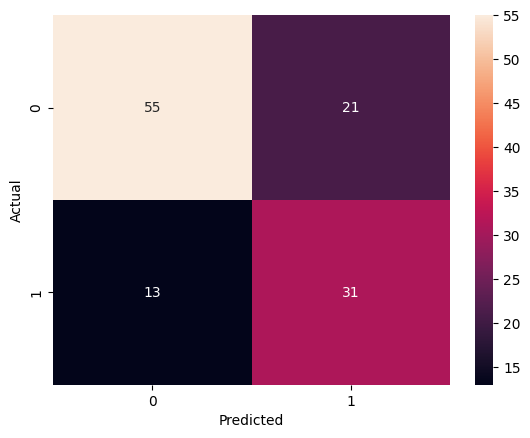

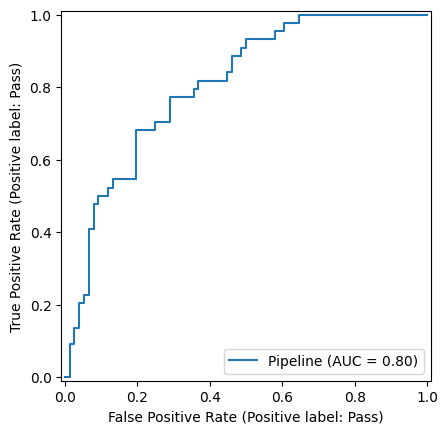

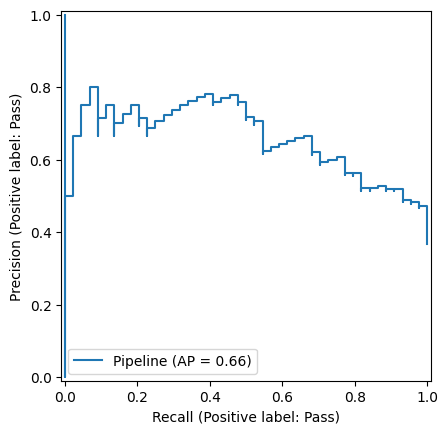

In [ ]:
# Train & Evaluation
def evaluate_model(model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)
    y_pred_Proba = model.predict_proba(X_test)[:, 1]

    # Convert y_test to numerical labels for metrics where pos_label is not accepted
    y_test_numeric = y_test.map({'Fail': 0, 'Pass': 1})

    y_pred = (y_pred_Proba >= 0.5).astype(int)

    print('ROC AUC Score:', roc_auc_score(y_test_numeric, y_pred_Proba))
    print('Average Precision Score:', average_precision_score(y_test_numeric, y_pred_Proba))
    print('Accuracy Score:', accuracy_score(y_test_numeric, y_pred))
    print('Confusion Matrix:\n', confusion_matrix(y_test_numeric, y_pred))
    print('Classification Report:\n', classification_report(y_test_numeric, y_pred))

    cm = confusion_matrix(y_test_numeric, y_pred)
    sns.heatmap(cm, annot=True, fmt='d')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

    # For RocCurveDisplay and PrecisionRecallDisplay, use original y_test with pos_label
    RocCurveDisplay.from_estimator(model, X_test, y_test, pos_label='Pass')
    plt.show()

    PrecisionRecallDisplay.from_estimator(model, X_test, y_test, pos_label='Pass')
    plt.show()

evaluate_model(lr_pipeline, X_train, X_test, y_train, y_test)

ROC AUC Score: 0.7564294258373205
Average Precision Score: 0.6129784329934538
Accuracy Score: 0.7166666666666667
Confusion Matrix:
 [[54 22]
 [12 32]]
Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.71      0.76        76
           1       0.59      0.73      0.65        44

    accuracy                           0.72       120
   macro avg       0.71      0.72      0.71       120
weighted avg       0.74      0.72      0.72       120



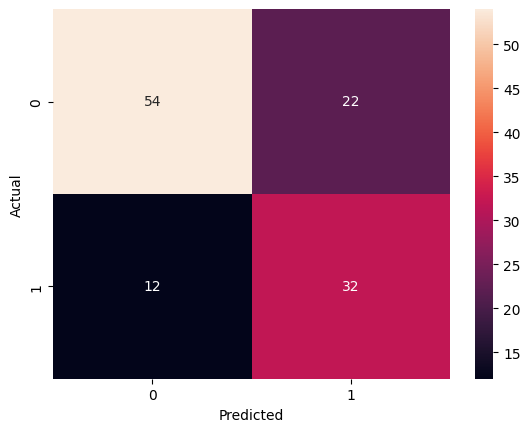

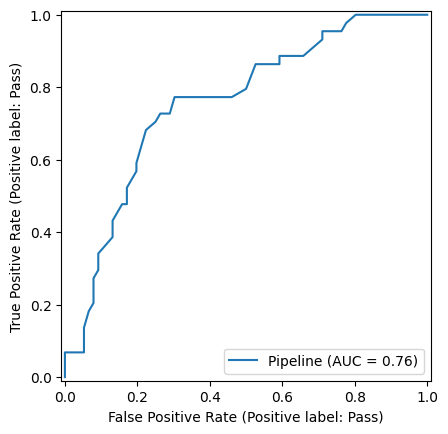

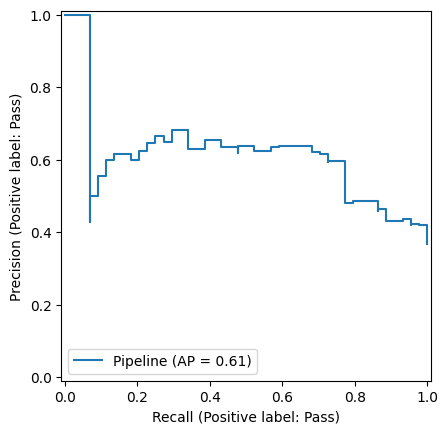

In [ ]:
evaluate_model(rf_pipeline, X_train, X_test, y_train, y_test)

In [ ]:
# Save model
final_model = lr_pipeline
joblib.dump(final_model, 'final_model.pkl')

['final_model.pkl']

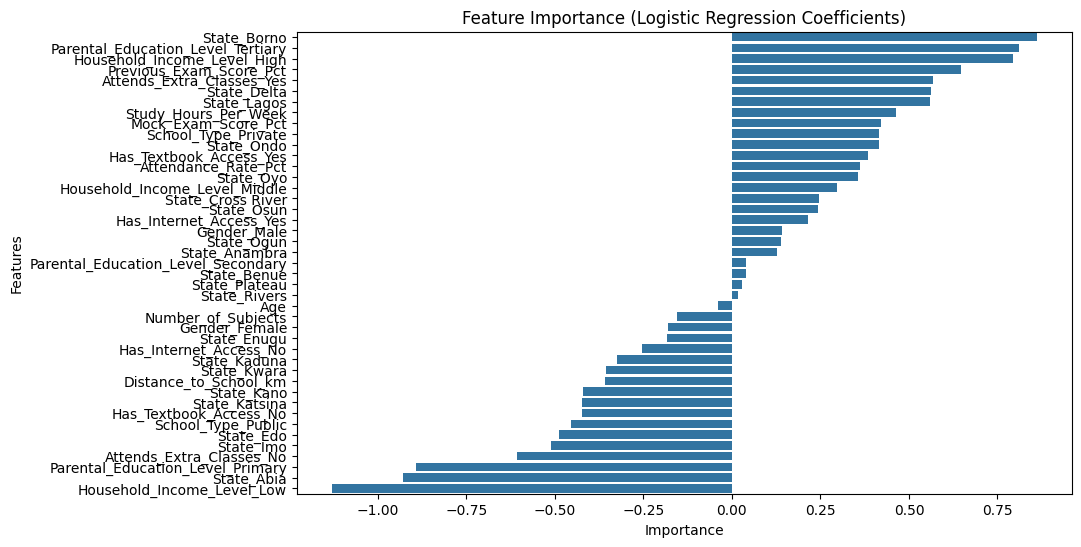

In [ ]:
# feature importance
# Fit the final_model (Logistic Regression pipeline) to the training data
final_model.fit(X_train, y_train)

preproc = final_model.named_steps['preprocessor']
num_features = numeric_features
cat_features = categorical_features

# Access the fitted one-hot encoder from the preprocessor
cat_encoder = preproc.named_transformers_['cat'].named_steps['onehot']
cat_features_names = cat_encoder.get_feature_names_out(cat_features)

all_features_names = np.concatenate([num_features, cat_features_names])

# Get coefficients from the fitted Logistic Regression classifier
importances = final_model.named_steps['classifier'].coef_[0]

fi = pd.Series(importances, index=all_features_names).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=fi.values, y=fi.index)
plt.xlabel('Importance')
plt.ylabel('Features')
plt.title('Feature Importance (Logistic Regression Coefficients)')
plt.show()